# Get to Know a Dataset: 
# NeMO Human and Mammalian Brain Atlas BRAIN Consortium Data

The Neuroscience Multi-Omic Archive (NeMO Archive; (nemoarchive.org)[nemoarchive.org] serves as the primary repository for genomics data from the [Brain Initiative](https://braininitiative.nih.gov/). Our data is a curated resource containing transcriptomic and epigenomic data from over 50 million brain cells, including single-cell genomic data from major regions of adult and prenatal human and mouse brains, as well as substantial single-cell genomic data from non-human primates.

This notebook serves as a guided tour of the NeMO Human and Mammalian Brain Atlas [🔗](https://registry.opendata.aws/[NeMO_archive.yaml) dataset. More usage examples, tutorials for other AWS Open Data projects can be found at the [Registry of Open Data on AWS](https://registry.opendata.aws/).

NOTE: 
- We are developing an API to access all the NeMO AWS Open Data which will enable query and retreival based on all relevant metadata. Please contact nemo@som.umaryland.edu for details. 
- Our current web resource has an API. Documentation can be found here: [🔗](https://nemoarchive.org/resources/nemo-api-overview.php). 

Please have fun and thank you for exploring the NeMO Human and Mammalian Brain Atlas BRAIN Consortium Data!

### Q: How have you organized your dataset? Help us understand the key prefix structure of your S3 bucket.

At the top level of our S3 bucket, we have a single key prefix "nemo-public-preview.s3" that in turn contains:

 1. README.txt
 2. License.txt
 2. data/
 3. metadata/
 4. docs/

Additional information can be found here: 
- Documentation for the NeMO archive. [🔗](https://github.com/nemoarchive)
- Organization of the AWS file structure below data. [🔗](https://github.com/owhite/AWS_NEMO/blob/main/NEMO_organization.md)
- The file formats used in the sequence directories. [🔗](https://github.com/nemoarchive/documentation/blob/master/file_extensions.md)

First we will import the Python libraries required throughout this notebook.

In [ ]:
# This notebook requires the following additional libraries. 
# Running this for the first time may take a minute. 
# Install libraries using your preferred method for your environment, (e.g. pip, conda). 
# Note: chatGPT is fantastic at debugging error statements!

import json
import anndata as ad
import tempfile

from pprint import pprint

import boto3, polars, matplotlib.pyplot as plt
from botocore import UNSIGNED
from botocore.config import Config

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

Next, we will review the structure of dataset by listing the top level directories in our S3 bucket:

In [2]:
### Review entry of the NeMO S3 bucket

# Top-level NeMO S3 bucket 
bucket = "nemo-test-filesystem"

chandelier_key = "data/other/lein/transcriptome/sncell/10x_v3/human/processed/counts/human_var_scVI_Chandelier.h5ad"
endo_key = "data/other/lein/transcriptome/sncell/10x_v3/human/processed/counts/human_var_scVI_Endo.h5ad"


# This is a public bucket and we don't need to sign requests.
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

# Print the items in the top-level prefixes
for item in s3.list_objects_v2(Bucket=bucket, Delimiter='/')['CommonPrefixes']:
    print(item['Prefix'])


data/
docs/
metadata/


At the top-level dataset, we see that the data have been separated into three programs: "bican", "biccn", and "other"

Next, let's introduce some terms:

**PROGRAM:** A program is a coordinated, multi-institution research effort funded under a common strategic initiative (typically by NIH or another funding agency) to address a broad scientific objective. A program encompasses multiple independently led projects that collectively contribute to shared goals, standards, and deliverables. Programs often span multiple institutions and laboratories, and include multiple principal investigators (PIs).

**PROJECT:** A project is a defined research effort within a program, typically led by a principal investigator or investigator team, focused on a specific scientific question, dataset, or technical objective. Projects operate semi-independently but align with the broader goals and standards of the program.

There are two important caveats to the project definition: 
- For legacy reasons "grant" and "project" are used interchangeably. 
- Multiple funded efforts can be agregated into one project. 

The intention is that our heirarchical directory tree reflects this aggregation:
<pre>
Program (e.g., bican)
├── Project A (PI-led)
├── Project B (PI-led)
├── Project C (multi-institution)
│   ├── Project C.1 (PI-led)
│   └── Project C.2 (PI-led)
└── Project D (PI-led)
</pre>

So in our case the contents in the data directory structure reflects these program:
<pre>
bican/
biccn/
other/
</pre>

... which are two important NIH programs: the BRAIN Initiative Cell Atlas Network (BICAN) and BRAIN Initiative Cell Census Network (BICCN).

Then what you see here is that "grant" is showing a collection of projects, with the term "rf1_macosko" reflecting the project name, as in: 

<pre>
biccn/
    grant/
        rf1_macosko/
</pre>

In some cases there are grant-projects nested under the top-level program, e.g.: 

<pre>
bican/
    grant/
        BICAN_Dev_Mouse/
            aibs/
        BICAN_Dev_Multiomics/
            ucla_luo/
</pre>

Further down the heirarchical, several sequencing modalities are used for these projects, such as transcriptome, epigenome, multimodal and are reflected in the naming structure of next tier of the directory tree. Under each of these trees we have listed directories that contain the sequence information, e.g.: 

<pre>
bican/
    grant/
        BICAN_Dev_Mouse/
            aibs/
                transcriptome/
                    cells/
                        SEQUENCE_DIRECTORIES:296
</pre>

This document provides the entire NeMO human and mammalian brain atlas with the truncated sequence directories: [nemo_tree_pruned.txt](nemo_tree_pruned.txt)

We can get a partial listing of all our directories inside of /data/other with the program below.

In [3]:
# List the first 20 directories within the 'data/other' prefix.
for i, item in enumerate(s3.list_objects_v2(Bucket=bucket, Prefix='data/other/', MaxKeys=100)['Contents']):
    if i >= 20:
        break
    print(item['Key'])

data/other/
data/other/lein/transcriptome/sncell/10x_v3/human/processed/counts/human_var_scVI_Chandelier.h5ad
data/other/lein/transcriptome/sncell/10x_v3/human/processed/counts/human_var_scVI_Endo.h5ad
data/other/tmp.txt


### Q: What data formats are present in your dataset? What kinds of data are stored using these formats? Can you give any advice for how you work with these data formats?

Not all, but the bulk of our data are H5AD files.  H5AD is common data format used to store single-cell biology datasets (especially RNA sequencing). They are widely used in computational biology workflows such as scanpy. A .h5ad file stores a matrix of measurements plus rich metadata in a single binary container which often includes:
- rows = cells
- columns = genes
- values = gene expression counts
- metadata = annotations about cells, genes, experiments

Think of it as a spreadsheet that can contain metadata tables, embeddings and graphs all stored efficiently in one file. 

A more complete list of files that can be obtained from the NeMO Archive is listed here: [[LINK](https://github.com/nemoarchive/documentation/blob/master/file_extensions.md)].

In [4]:
# Open a file and run anndata on it

endo_key = "data/other/lein/transcriptome/sncell/10x_v3/human/processed/counts/human_var_scVI_Endo.h5ad"

with tempfile.NamedTemporaryFile(suffix=".h5ad") as tmp_file:
    s3.download_file(bucket, endo_key, tmp_file.name)
    adata = ad.read_h5ad(tmp_file.name)

print(adata)
print("\nobs columns:")
print(list(adata.obs.columns))
print("\nvar columns:")
print(list(adata.var.columns))
print("\nobs preview:")
print(adata.obs.head(10))
print("\nvar preview:")
print(adata.var.head(10))

AnnData object with n_obs × n_vars = 582 × 29691
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample_id_x', 'bc', 'ar_id', 'umi.counts', 'barcodes', 'gene.counts.0', 'gene.counts.1', 'gene.counts.4', 'gene.counts.8', 'gene.counts.16', 'gene.counts.32', 'gene.counts.64', 'exclude', 'exp_component_name', 'exp_component_vendor_name', 'batch', 'batch_vendor_name', 'tube', 'tube_internal_name', 'tube_contents_nm', 'tube_contents_nm_from_vendor', 'tube_avg_size_bp', 'tube_input_fmol', 'r1_index', 'r2_index', 'index_sequence_pair', 'organism', 'reference_id', 'facs_container', 'sample_name', 'patched_cell_container', 'cell_name', 'cell_id', 'studies', 'hemisphere_name', 'sample_quantity_count', 'expc_cell_capture', 'sample_quantity_pg', 'donor_name', 'external_donor_name', 'age', 'species', 'sex', 'control', 'cell_prep_type', 'full_genotype', 'facs_population_plan', 'cre_line', 'reporter', 'injection_roi', 'injection_method', 'injection_materials', 'injection_type', 'roi', 'patchseq_

### Q: Can you show us an example of downloading and loading data from your dataset?

Sure! As an example, let us load up and look into some package data as found in a
[[sequence file](https://nemo-test-filesystem.s3.us-east-2.amazonaws.com/data/biccn/lein/transcriptome/sncell/10x_v3/human/processed/counts/human_var_scVI_Endo.h5ad)]. 
 

In this example, we use the `.h5ad` file from the NeMO S3 bucket and open it with `anndata`, a Python package commonly used for working with single-cell genomics data. Rather than treating the file as raw binary data, `anndata` interprets it as a structured dataset containing a data matrix together with annotations about cells and genes.

We then print a summary of the `AnnData` object and preview the `obs` and `var` tables. This gives us a quick view of the dataset’s dimensions, the metadata available for cells and features, and the general structure of the file before moving on to more detailed exploration.

In [5]:
print("Shape:", adata.shape)
print("\nobs columns:")
print(list(adata.obs.columns))
print("\nvar columns:")
print(list(adata.var.columns))

print("\nFirst 5 rows of obs:")
display(adata.obs.head())

print("\nFirst 5 rows of var:")
display(adata.var.head())

Shape: (582, 29691)

obs columns:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample_id_x', 'bc', 'ar_id', 'umi.counts', 'barcodes', 'gene.counts.0', 'gene.counts.1', 'gene.counts.4', 'gene.counts.8', 'gene.counts.16', 'gene.counts.32', 'gene.counts.64', 'exclude', 'exp_component_name', 'exp_component_vendor_name', 'batch', 'batch_vendor_name', 'tube', 'tube_internal_name', 'tube_contents_nm', 'tube_contents_nm_from_vendor', 'tube_avg_size_bp', 'tube_input_fmol', 'r1_index', 'r2_index', 'index_sequence_pair', 'organism', 'reference_id', 'facs_container', 'sample_name', 'patched_cell_container', 'cell_name', 'cell_id', 'studies', 'hemisphere_name', 'sample_quantity_count', 'expc_cell_capture', 'sample_quantity_pg', 'donor_name', 'external_donor_name', 'age', 'species', 'sex', 'control', 'cell_prep_type', 'full_genotype', 'facs_population_plan', 'cre_line', 'reporter', 'injection_roi', 'injection_method', 'injection_materials', 'injection_type', 'roi', 'patchseq_roi', 'medical_conditio

,orig.ident,nCount_RNA,nFeature_RNA,sample_id_x,bc,ar_id,umi.counts,barcodes,gene.counts.0,gene.counts.1,...,Vip_9,supertype_scANVI,supertype_conf_scANVI,class_y,subclass_y,supertype_y,sample_id_y,_scvi_batch,_scvi_labels,leiden_scVI
CAGATCACAGCGAGTA-L8TX_200625_01_H08-1034780098-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,SeuratProject,2030.0,1293,CAGATCACAGCGAGTA-L8TX_200625_01_H08-1034780098,CAGATCACAGCGAGTA,1.034780e+09,2030.0,CAGATCACAGCGAGTA,1293.0,232.0,...,NaN,Endo_1,1.0,Unknown,Unknown,Unknown,CAGATCACAGCGAGTA-L8TX_200625_01_H08-1034780098-1,0,2,0
CATAAGCTCACAGTGT-L8TX_200625_01_H08-1034780098-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,SeuratProject,2968.0,1730,CATAAGCTCACAGTGT-L8TX_200625_01_H08-1034780098,CATAAGCTCACAGTGT,1.034780e+09,2968.0,CATAAGCTCACAGTGT,1730.0,494.0,...,NaN,Endo_1,1.0,Unknown,Unknown,Unknown,CATAAGCTCACAGTGT-L8TX_200625_01_H08-1034780098-1,0,2,0
CGTCAAATCCACGTCT-L8TX_200625_01_H08-1034780098-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,SeuratProject,6417.0,3141,CGTCAAATCCACGTCT-L8TX_200625_01_H08-1034780098,CGTCAAATCCACGTCT,1.034780e+09,6417.0,CGTCAAATCCACGTCT,3141.0,1135.0,...,NaN,Endo_1,1.0,Unknown,Unknown,Unknown,CGTCAAATCCACGTCT-L8TX_200625_01_H08-1034780098-1,0,2,0
GACTCTCCACTATCCC-L8TX_200625_01_H08-1034780098-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,SeuratProject,52423.0,9803,GACTCTCCACTATCCC-L8TX_200625_01_H08-1034780098,GACTCTCCACTATCCC,1.034780e+09,52423.0,GACTCTCCACTATCCC,9803.0,6308.0,...,NaN,Endo_1,1.0,Unknown,Unknown,Unknown,GACTCTCCACTATCCC-L8TX_200625_01_H08-1034780098-1,0,2,0
GCCGTGATCACTCTTA-L8TX_200625_01_H08-1034780098-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,SeuratProject,3092.0,1877,GCCGTGATCACTCTTA-L8TX_200625_01_H08-1034780098,GCCGTGATCACTCTTA,1.034780e+09,3092.0,GCCGTGATCACTCTTA,1877.0,462.0,...,NaN,Endo_1,1.0,Unknown,Unknown,Unknown,GCCGTGATCACTCTTA-L8TX_200625_01_H08-1034780098-1,0,2,3



First 5 rows of var:


,gene_ids,highly_variable,highly_variable_rank,means,variances,variances_norm
WASH7P,WASH7P,False,NaN,0.029210,0.035290,0.866708
LOC105379213,LOC105379213,False,NaN,0.003436,0.003431,0.942155
LOC729737,LOC729737,False,NaN,0.010309,0.010221,0.849351
LOC100996442,LOC100996442,False,NaN,0.000000,0.000000,0.000000
LOC102723897,LOC102723897,False,NaN,0.010309,0.010221,0.849351


### Q: A picture is worth a thousand words. Show us a visual from your dataset that either illustrates something informative about your dataset.

Can do. In this example, we use the `AnnData` object to calculate the total signal recorded for each cell and then plot those values as a histogram. This gives us a quick view of how counts are distributed across the dataset and helps reveal whether most cells have similar coverage or whether there is a wide spread in sequencing depth.

Visual summaries like this are often a useful first quality-control step in single-cell analysis. They can help identify unusually low-coverage or high-coverage cells and provide a first impression of the overall structure of the dataset before moving on to downstream analysis.


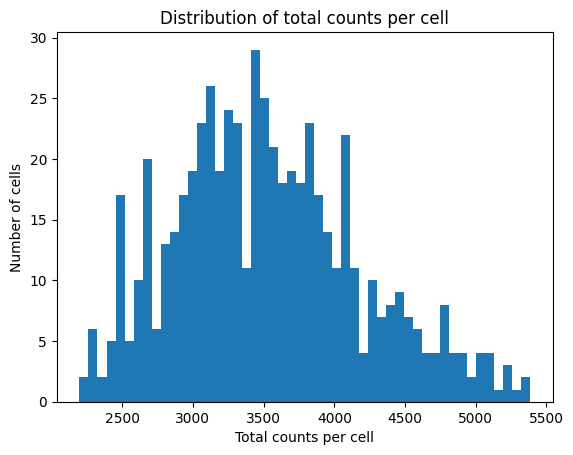

In [6]:
cell_totals = np.asarray(adata.X.sum(axis=1)).ravel()

plt.hist(cell_totals, bins=50)
plt.xlabel("Total counts per cell")
plt.ylabel("Number of cells")
plt.title("Distribution of total counts per cell")
plt.show()

In this example, we use the `AnnData` object to create violin plots that summarize both dataset-level metadata and gene expression values. Violin plots are useful because they show the full distribution of values, rather than only a single summary statistic such as a mean or median.

We first visualize selected metadata fields stored in `adata.obs`, which gives a quick view of how per-cell measurements vary across the dataset. We then plot expression distributions for a small set of example genes, showing how values differ across cells. Together, these plots provide a compact way to explore variability in both cell-level quality metrics and biologically meaningful features within the dataset.


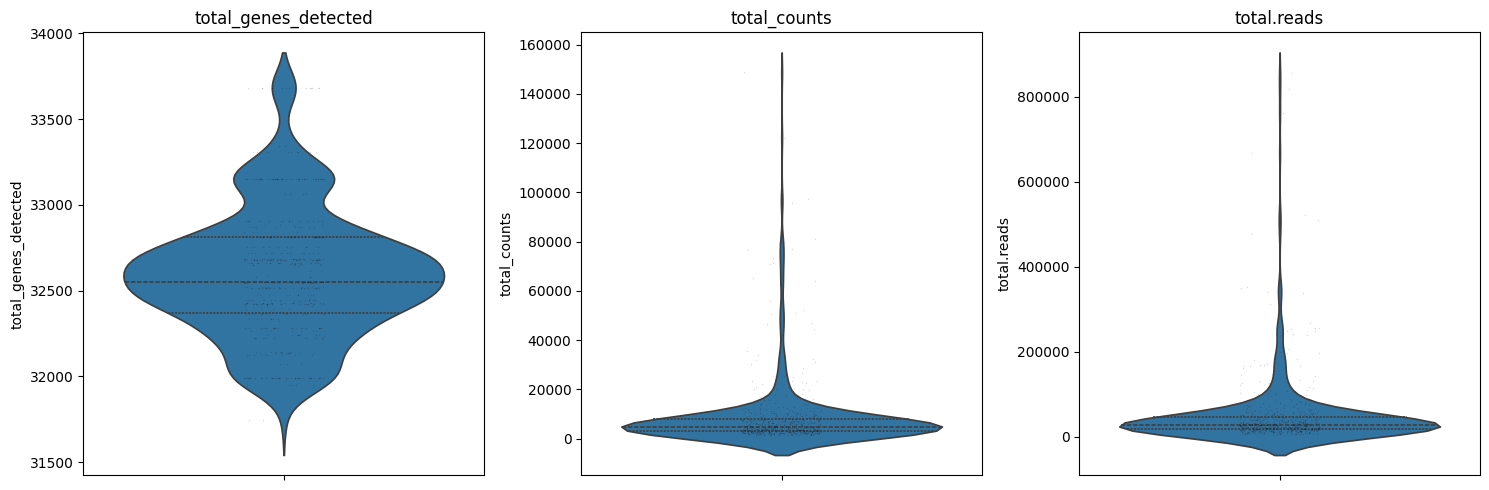

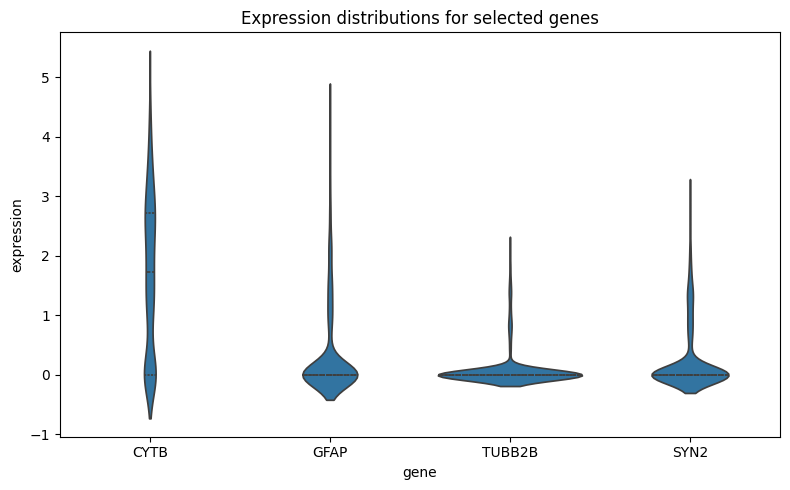

In [7]:
# Violin plots from the current AnnData object

# First, reproduce the metadata-style violin plots from adata.obs.
obs_candidates = ["total_genes_detected", "total_counts", "total.reads"]
obs_cols = [col for col in obs_candidates if col in adata.obs.columns]

if obs_cols:
    fig, axes = plt.subplots(1, len(obs_cols), figsize=(5 * len(obs_cols), 5))

    if len(obs_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, obs_cols):
        plot_df = adata.obs[[col]].dropna().copy()
        sns.violinplot(data=plot_df, y=col, ax=ax, inner="quart")
        sns.stripplot(data=plot_df, y=col, ax=ax, color="black", size=1, alpha=0.15)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()
else:
    print("None of the expected metadata columns were found in adata.obs.")
    print("Available obs columns:")
    print(list(adata.obs.columns))


# Next, reproduce the gene-expression violin plots.
gene_candidates = ["CYTB", "GFAP", "TUBB2B", "SYN2"]
genes = [gene for gene in gene_candidates if gene in adata.var_names]

if genes:
    expr = adata[:, genes].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray()

    expr_df = pd.DataFrame(expr, columns=genes)
    long_df = expr_df.melt(var_name="gene", value_name="expression")

    plt.figure(figsize=(8, 5))
    sns.violinplot(data=long_df, x="gene", y="expression", inner="quart")
    plt.title("Expression distributions for selected genes")
    plt.tight_layout()
    plt.show()
else:
    print("None of the expected genes were found in adata.var_names.")
    print("Example available genes:")
    print(list(adata.var_names[:20]))


### Q: What is one question that you have answered using these data? Can you show us how you came to that answer?
Goal: Explore a small portion of the data from the recent Science paper: *Interindividual variation in human cortical cell type abundance and expression*, hosted at NeMO Archive.

The data from this publication:
<pre style="font-size: 10px; line-height: 1.2;">
Johansen N, Somasundaram S, Travaglini KJ, Yanny AM, Shumyatcher M, Casper T, Cobbs C, 
Dee N, Ellenbogen R, Ferreira M, Goldy J, Guzman J, Gwinn R, Hirschstein D, Jorstad NL, 
Keene CD, Ko A, Levi BP, Ojemann JG, Pham T, Shapovalova N, Silbergeld D, Sulc J, 
Torkelson A, Tung H, Smith K, Lein ES, Bakken TE, Hodge RD, Miller JA. 
Interindividual variation in human cortical cell type abundance and expression. 
Science. 2023 Oct 13;382(6667):eadf2359. doi: 10.1126/science.adf2359. Epub 2023 Oct 13. 
PMID: 37824649; PMCID: PMC11702338.
</pre>

You can see more information about this collection at the NeMO Archive. 
See: https://assets.nemoarchive.org/nemo:dat-p3eei0g

Using just one file from this collection, we can visualize the precomputed UMAP embedding stored in the `AnnData` object and color each point by its predicted cell type annotation. UMAP is a dimensionality-reduction method that places cells with similar molecular profiles near one another in a two-dimensional space, making it easier to see broad structure in a high-dimensional single-cell dataset.

Each point in the plot represents one cell, and colors indicate the assigned cell type label. Clusters of similarly colored points suggest groups of cells with shared transcriptional profiles, while separation between clusters highlights differences between cell populations. So basically this plot is a graphic, statistically based method that helps us see how cells group together based on similarities in their gene expression, revealing distinct cell types and broad patterns of cellular diversity in the dataset. This kind of visualization is a common first step for exploring cellular diversity within a single-cell dataset. 


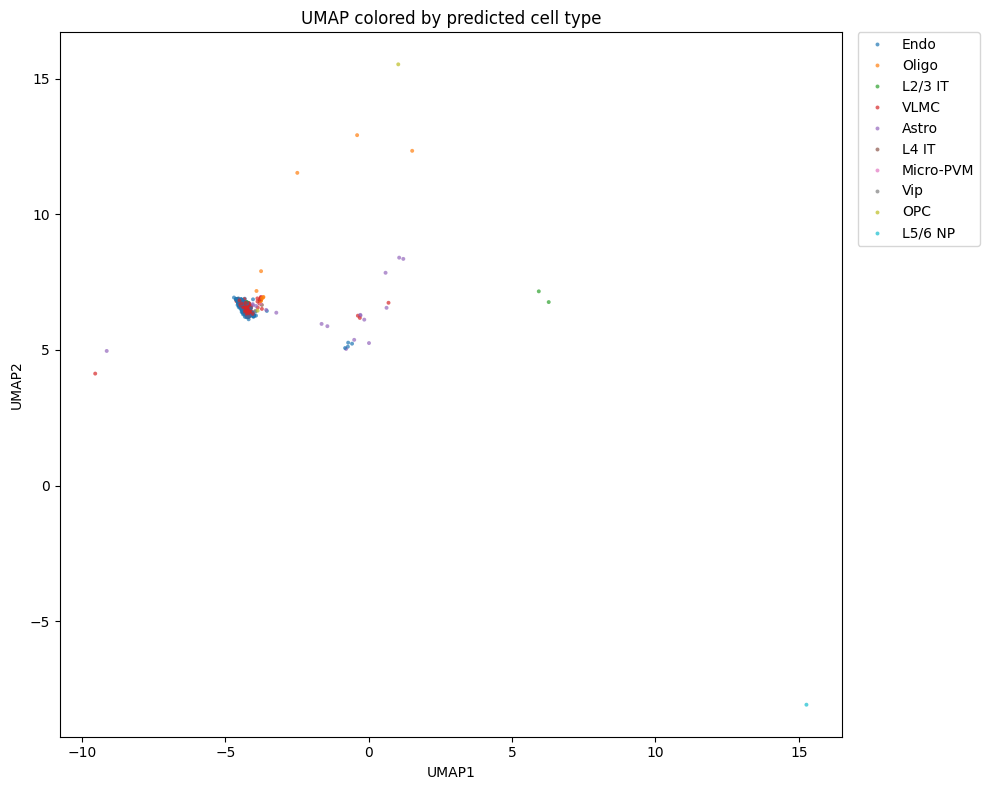

In [8]:
umap = adata.obsm["X_umap"]

plot_df = pd.DataFrame({
    "UMAP1": umap[:, 0],
    "UMAP2": umap[:, 1],
    "cell_type": adata.obs["predicted.id"].astype(str).values
})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df,
    x="UMAP1",
    y="UMAP2",
    hue="cell_type",
    s=8,
    alpha=0.7,
    linewidth=0
)

plt.title("UMAP colored by predicted cell type")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

### Q: What is one unanswered question that you think could be answered using these data? 
### Do you have any recommendations or advice for someone wanting to answer this question?

Let's start by reviewing the conclusions from this [published work](https://pubmed.ncbi.nlm.nih.gov/37824649/) that show that most cortical cell types are conserved across individuals, but measurable variation exists in gene expression and cell-type abundance, particularly in glutamatergic neurons and microglia . This suggests that individual-level biological differences may influence brain function in ways not yet fully understood. One quesiton scientists eventually hope to answer is: _"Could subtle differences in gene expression across human brain cell types help explain why individuals vary in cognitive traits or vulnerability to neurological disease?"_

**Advice for someone wanting to answer this question**
1. _Build foundational knowledge in the field_

Develop a working understanding of:
- single-cell RNA sequencing (snRNA-seq)
- gene expression analysis
- cell type classification
- statistical genetics (eQTLs)
- neuroscience basics (neurons, glia, cortical organization)

**Even a modest background allows meaningful exploration of large biological datasets.**

2. _Develop practical bioinformatics skills_

Key technical capabilities include:
- working with .h5ad and similar formats
- Python tools such as scanpy, anndata, numpy, pandas
- visualization methods (UMAP, clustering)
- reproducible workflows

**More importanly, remember that MANY discoveries are being generated by brain research, and integration across these datasets are going to continue for a long time.**

3. _So start with simple exploratory analyses_

Examples of approachable first steps:
- compare gene expression variability across donors
- identify cell types with the highest variability
- explore associations between metadata (age, sex, disease) and expression
- visualize clusters or gradients in cell state space

**... and remember datasets in our atlases are meant to provide a baseline knowledge that can support many downstream questions!**

4. Leverage publicly hosted datasets

_Large consortia have already generated extremely rich data resources, including:_

- single-cell transcriptomics
- genomic variation
- curated cell type annotations

By accessing the data that we host, combining it with publicly available tools, and iteratively refining your analyses, meaningful insights are achievable even without wet-lab experimentation.

This field is still young, and many important questions remain unanswered. Dont hesitate to ask questions, and remember the resources provided by chatGPT or Gemina are incredibly powerful. You are destined for greatness -- you can acheive wonderful things by learning about neurobiology, developing skills in bioinformatic analysis, and accessing the data hosted here. 